# Econ 8208 Assignment 7

- Author: Yuxuan Zhao
- Date: 2026-04-18

In [44]:
using LinearAlgebra
using Plots
using CSV

# Shared helpers from the course library
include("../ECON8208Tools.jl")
import .ECON8208Tools as tools

# HW7-specific helpers: pack/unpack theta, steady state, state-space,
# Kalman likelihood, counterfactual simulation, plotting utilities.
include("HW7Tools.jl")
using .HW7Tools

ENV["GKSwstype"] = "100"
gr()


Plots.GRBackend()

# HW 7

Compute equilibria of the following growth model with accounting wedges:

$$
\begin{aligned}
\max_{\{c_t,x_t,\ell_t\}} \quad
& E_0 \sum_{t=0}^{\infty} \beta^t
\left\{
\frac{(c_t \ell_t^{\psi})^{1-\sigma}}{1-\sigma}
\right\} N_t \\
\text{s.t.} \quad
& c_t + (1+\tau_t^x) x_t = r_t k_t + (1-\tau_t^h) w_t h_t + \kappa_t, \\
& N_{t+1} k_{t+1} = \bigl[(1-\delta)k_t + x_t\bigr]N_t, \\
& h_t + \ell_t = 1, \\
& S_t = P_0 + P S_{t-1} + Q \epsilon_t, \\
& S_t = [\log z_t,\tau_t^h,\tau_t^x,\log g_t]', \\
& N_t = (1+\gamma_n)^t, \\
& c_t, x_t \ge 0 \quad \text{in all states.}
\end{aligned}
$$

The production technology is
$$
Y_t = K_t^\theta \bigl(Z_t H_t\bigr)^{1-\theta},
\qquad
Z_t = (1+\gamma_z)^t z_t,
$$
and factor prices satisfy
$$
r_t = \theta K_t^{\theta-1}(Z_t H_t)^{1-\theta},
\qquad
w_t = (1-\theta)K_t^\theta Z_t^{1-\theta} H_t^{-\theta}.
$$

In equilibrium, we impose the resource constraint:
$$
\begin{aligned}
C_t + X_t + G_t &= Y_t, \\
\end{aligned}
$$

The four accounting wedges are the efficiency wedge $z_t$, the labor wedge $\tau_t^h$, the investment wedge $\tau_t^x$, and the government spending wedge $g_t$.

The tasks are:

1. Use U.S. data to infer the wedges.
2. Input all wedges and show that the model and data match exactly.
3. Input wedges one at a time and interpret the results.


This model also has a balanced growth path because productivity grows at the labor-augmenting rate $\gamma_z$. Hence, before solving the equilibrium we detrend the variables that grow over time.

Define the detrended variables as

$$
\tilde c_t=\frac{c_t}{(1+\gamma_z)^t},\qquad
\tilde x_t=\frac{x_t}{(1+\gamma_z)^t},\qquad
\tilde k_t=\frac{k_t}{(1+\gamma_z)^t},
$$

$$
\tilde \kappa_t=\frac{\kappa_t}{(1+\gamma_z)^t},\qquad
\tilde g_t=\frac{g_t}{(1+\gamma_z)^t},\qquad
\tilde G_t=\frac{G_t}{N_t(1+\gamma_z)^t},\qquad
\tilde h_t=h_t,\qquad \tilde \ell_t=\ell_t,
$$

$$
\tilde Y_t=\frac{Y_t}{N_t(1+\gamma_z)^t},\qquad
\tilde K_t=\frac{K_t}{N_t(1+\gamma_z)^t},\qquad
\tilde H_t=\frac{H_t}{N_t},\qquad
\tilde r_t=r_t,\qquad
\tilde w_t=\frac{w_t}{(1+\gamma_z)^t},
$$

$$
\tilde X_t=\frac{X_t}{N_t(1+\gamma_z)^t},\qquad
\tilde C_t=\frac{C_t}{N_t(1+\gamma_z)^t}.
$$

Then period utility becomes

$$
N_t\frac{(c_t\ell_t^{\psi})^{1-\sigma}}{1-\sigma}
=(1+\gamma_n)^t(1+\gamma_z)^{t(1-\sigma)}
\frac{(\tilde c_t\tilde\ell_t^{\psi})^{1-\sigma}}{1-\sigma}.
$$

Therefore, after detrending, the effective discount factor is

$$
\tilde\beta=\beta(1+\gamma_n)(1+\gamma_z)^{1-\sigma}.
$$


The detrended capital accumulation equation is

$$
\tilde k_{t+1}
=\frac{(1-\delta)\tilde k_t+\tilde x_t}{(1+\gamma_n)(1+\gamma_z)}.
$$

Therefore, the detrended household problem can be written as

$$
\begin{aligned}
\max_{\{\tilde c_t,\tilde x_t,\tilde\ell_t\}}\quad
& E_0\sum_{t=0}^{\infty}\tilde\beta^t
\left\{\frac{(\tilde c_t\tilde\ell_t^{\psi})^{1-\sigma}}{1-\sigma}\right\} \\
\text{s.t.}\quad
& \tilde c_t+(1+\tau_{x,t})\tilde x_t
=\tilde r_t\tilde k_t+(1-\tau_{h,t})\tilde w_t\tilde h_t+\tilde\kappa_t, \\
& \tilde k_{t+1}=\frac{(1-\delta)\tilde k_t+\tilde x_t}{(1+\gamma_n)(1+\gamma_z)}, \\
& \tilde h_t+\tilde\ell_t=1, \\
& S_t=P_0 + P S_{t-1}+Q\epsilon_t, \\
& S_t=[\log z_t,\tau_{h,t},\tau_{x,t},\log\tilde g_t]', \\
& \tilde c_t,\tilde x_t\ge 0 \quad \text{in all states.}
\end{aligned}
$$

We have

$$
\tilde Y_t=\frac{Y_t}{N_t(1+\gamma_z)^t},\qquad
\tilde K_t=\frac{K_t}{N_t(1+\gamma_z)^t},\qquad
\tilde H_t=\frac{H_t}{N_t}.
$$

The detrended production function and factor prices are

$$
\tilde Y_t=\tilde K_t^{\theta}(z_t\tilde H_t)^{1-\theta},
\qquad
\tilde r_t=\theta\tilde K_t^{\theta-1}(z_t\tilde H_t)^{1-\theta},
\qquad
\tilde w_t=(1-\theta)\tilde K_t^{\theta}z_t^{1-\theta}\tilde H_t^{-\theta}.
$$

Hence, the detrended market clearing conditions can be written as

$$
\tilde K_t=\tilde k_t,\qquad
\tilde G_t=\tilde g_t,\qquad
\tilde C_t=\tilde c_t,\qquad
\tilde X_t=\tilde x_t,\qquad
\tilde H_t=\tilde h_t,
$$

$$
\tilde K_{t+1}=\frac{(1-\delta)\tilde K_t+\tilde X_t}{(1+\gamma_n)(1+\gamma_z)},
\qquad
\tilde C_t+\tilde X_t+\tilde G_t=\tilde Y_t.
$$


# 4. Data Objects We Need

We use cleaned U.S. national accounts data stored in

`HW7/data/raw_data.xlsx`.

For the BCA wedge calculation, we only need data analogues for output, consumption, investment, and labor:

$$
\{\tilde y_t,\tilde c_t,\tilde x_t,\tilde h_t\}.
$$


# 5. Calibration Choices

We use the structural parameters calibrated in `HW6.ipynb`.

$$
\beta = 0.97,
\qquad
\psi = 1.55,
\qquad
\sigma = 2.00,
$$

$$
\gamma_n = 0.01,
\qquad
\gamma_z = 0.02,
$$

$$
\theta = 0.368,
\qquad
\delta = 0.072.
$$





## (a) Use Data for the United States to Infer the Wedges

Using the cleaned data, three objects are directly pinned down by data and static equilibrium conditions. In this section all variables are detrended model analogues, so we use tildes in the formulas.

### Government/resource wedge

We define the government spending wedge as the residual in the aggregate resource constraint:

$$
\tilde g_t = \tilde y_t - \tilde c_t - \tilde x_t.
$$

This is broader than government purchases alone. It absorbs government spending, net exports, and any other resource-accounting components not explicitly modeled.


### Efficiency wedge

From production,

$$\tilde y_t = \tilde k_t^{\theta}(z_t \tilde h_t)^{1-\theta},$$

We have:

$$
z_t = \left(\frac{\tilde y_t}{\tilde k_t^{\theta}\tilde h_t^{1-\theta}}\right)^{\frac{1}{1-\theta}}
\quad \Rightarrow \quad
\log z_t = \frac{\log \tilde y_t - \theta\log \tilde k_t - (1-\theta)\log \tilde h_t}{1-\theta}.
$$

### Labor wedge

The household labor FOC is

$$\frac{\psi \tilde c_t}{1-\tilde h_t} = (1-\tau_{h,t})\tilde w_t,$$

and the competitive wage is

$$\tilde w_t = (1-\theta)\frac{\tilde y_t}{\tilde h_t}.$$

Therefore,

$$1-\tau_{h,t}=\frac{\psi \tilde c_t}{1-\tilde h_t}\bigg/\left((1-\theta)\frac{\tilde y_t}{\tilde h_t}\right),$$

or

$$\tau_{h,t}=1-\frac{\psi}{1-\theta}\frac{\tilde c_t}{\tilde y_t}\frac{\tilde h_t}{1-\tilde h_t}.$$


### Inferring the Investment Wedge


The investment wedge cannot be inferred from a purely static equation, because it appears in the intertemporal Euler equation:

$$
(1+\tau_{x,t})U_{c,t}
=
\hat\beta E_t
\left[
U_{c,t+1}
\left(
\theta\frac{\tilde y_{t+1}}{\tilde k_{t+1}}
+
(1-\delta)(1+\tau_{x,t+1})
\right)
\right].
$$

This equation depends on expectations about future marginal utility, future capital returns, and future investment wedges. Therefore, the current investment wedge $\tau_{x,t}$ cannot be backed out from current-period data alone.

Assuming $\tau_{x,t}$ is latent state, $\tilde y_t, \tilde x_t, \tilde h_t, \tilde g_t$ are observed variables, we can use Kalman filter to infer the hidden state $\tau_{x,t}$ from the observed data.




## 1. Build the Data Used in HW7

The first object we need is the BCA data vector

$$
\{Y_t, C_t, X_t, K_t, H_t, G_t\}_{t=1}^T .
$$

We use the cleaned annual national accounts data in `HW7/data/raw_data.xlsx`. All real aggregate variables are converted into real per-capita model units.

Output is real GDP per capita:

$$
Y_t = \frac{\text{real GDP}_t}{N_t}.
$$

Consumption, investment, and capital are constructed in the same real per-capita units by the "share times real-GDP" convention:

$$
C_t = \frac{\text{PCE}_t}{\text{nominal GDP}_t}\cdot Y_t,
\qquad
X_t = \frac{\text{gross investment}_t}{\text{nominal GDP}_t}\cdot Y_t,
\qquad
K_t = \frac{\text{private fixed assets}_t}{\text{nominal GDP}_t}\cdot Y_t.
$$

Labor is the hours fraction $h_t \in (0,1)$, built from BEA tables 6.9B and 6.7B as

$$
H_t = \frac{\text{hours of employees} + \text{hours of self-employed}}{\text{total workers} \times 52 \times 100 / 1000}.
$$

Finally, following the BCA resource-constraint logic we construct the government/resource wedge as the residual

$$
G_t = Y_t - C_t - X_t.
$$

So the output of Step 1 is the minimal data file

$$
\{Y_t, C_t, X_t, G_t, H_t, K_t\}.
$$


In [45]:
# -------------------------------------------------------
# Load the annual raw data and build the BCA per-capita series
# -------------------------------------------------------
path_data = joinpath(pwd(), "data", "raw_data.xlsx")
df_raw = tools.load_raw_data_hw6(path_data; start_year = 1948)
df, hours_df, _, _ = tools.compute_data_moments_hw6(df_raw)

bca_data = build_bca_per_capita(df, hours_df)

println("Loaded annual raw data: ", size(bca_data, 1), " obs, ",
        bca_data.year[1], " to ", bca_data.year[end])
first(bca_data, 5)


UndefVarError: UndefVarError: `build_bca_per_capita` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

## 2. Detrend the Data and Infer Static Wedges

### 2a. Calibrated structural parameters

We reuse the HW6 annual calibration:

$$
\beta = 0.97,\quad \psi = 1.55,\quad \sigma = 2.00,\quad \gamma_n = 0.01,\quad \gamma_z = 0.02,\quad \theta = 0.368,\quad \delta = 0.072.
$$

### 2b. Detrending

Variables on the balanced growth path are detrended by dividing by $(1+\gamma_z)^t$:

$$
\tilde y_t = \frac{y_t}{(1+\gamma_z)^t},\qquad
\tilde c_t = \frac{c_t}{(1+\gamma_z)^t},\qquad
\tilde x_t = \frac{x_t}{(1+\gamma_z)^t},\qquad
\tilde k_t = \frac{k_t}{(1+\gamma_z)^t},\qquad
\tilde g_t = \frac{g_t}{(1+\gamma_z)^t}.
$$

Hours $h_t$ is already stationary and stays as is.

### 2c. Static wedges from first-order conditions

The efficiency wedge is inverted from the production function $\tilde y_t = \tilde k_t^\theta (z_t h_t)^{1-\theta}$:

$$
\log z_t = \frac{1}{1-\theta}\Big[\log \tilde y_t - \theta \log \tilde k_t - (1-\theta)\log h_t\Big].
$$

The labor wedge is inverted from the static labor FOC $\psi\, \tilde c_t / (1-h_t) = (1-\tau_{h,t})(1-\theta)\,\tilde y_t / h_t$:

$$
\tau_{h,t} = 1 - \frac{\psi}{1-\theta}\cdot \frac{\tilde c_t}{\tilde y_t}\cdot \frac{h_t}{1-h_t}.
$$

The investment wedge $\tau_{x,t}$ is **not** pinned down by any static equation. It enters only through the intertemporal Euler equation and will be recovered later in Step 7, after MLE produces the state-space observation matrix $C$.

### Observables vector

The BCA observation vector used by the Kalman filter is

$$
Y_t = \big(\log \tilde y_t,\ \log \tilde x_t,\ \log h_t,\ \log \tilde g_t\big)'.
$$


In [46]:
# -------------------------------------------------------
# HW6 annual calibration (see HW6.ipynb Cell 30 and HW7 Cell 6)
# -------------------------------------------------------
hw7_params = (
    beta    = 0.97,
    psi     = 1.55,
    sigma   = 2.00,
    gamma_n = 0.01,
    gamma_z = 0.02,
    theta   = 0.368,
    delta   = 0.072,
)

# Detrend balanced-growth variables and invert the static (log z, tau_h, log g)
# wedges. Yobs is the Kalman-filter observation vector.
(; T, y_tilde, c_tilde, x_tilde, g_tilde, h_tilde, k_tilde,
   log_z, tau_h, log_g, Yobs, bca_static) =
    detrend_and_static_wedges(bca_data, hw7_params)

println("Step 2 done. T = ", T,
        ", sample = ", bca_data.year[1], " to ", bca_data.year[end])
println("log z: mean = ", tools.mean(log_z), ", std = ", tools.std(log_z))
println("tau_h: mean = ", tools.mean(tau_h), ", std = ", tools.std(tau_h))
println("log g: mean = ", tools.mean(log_g), ", std = ", tools.std(log_g))

first(bca_static, 5)


UndefVarError: UndefVarError: `detrend_and_static_wedges` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

## 3. Build the BCA State-Space System for a Candidate Wedge Process

### 3a. Parameter vector for the wedge process

The wedges $S_t=(\log z_t,\,\tau_{h,t},\,\tau_{x,t},\,\log g_t)'$ follow a VAR(1) with Gaussian innovations:

$$
S_{t+1}=(I-P)\bar S + P\, S_t + Q\, \varepsilon_{t+1},\qquad \varepsilon_{t+1}\sim\mathcal{N}(0,I_4).
$$

We stack the estimable parameters into a single vector

$$
\theta_{\text{mle}}=\big[\bar S;\ \mathrm{vec}(P);\ \mathrm{lowertri}(Q)\big]\in\mathbb{R}^{4+16+10}=\mathbb{R}^{30}.
$$

`pack_bca_theta` and `unpack_bca_theta` are inverse maps between $\theta_{\text{mle}}$ and the triple $(\bar S, P, Q)$.

### 3b. Steady state of the detrended economy

At any candidate $\bar S$, the detrended steady state follows from the Euler equation, the static labor FOC, and the resource constraint.

**Step 1. The household's FOC for capital.**

$$
(1+\tau_{x,t})\,U_{c,t} = \beta\, U_{c,t+1}\Big[\theta\,\frac{y_{t+1}}{k_{t+1}}+(1+\tau_{x,t+1})(1-\delta)\Big].
$$

**Step 2. Detrend.** Let $c_t=\tilde c_t(1+\gamma_z)^t$ and $k_t=\tilde k_t(1+\gamma_z)^t$. Then $U_{c,t}=c_t^{-\sigma}(1-l_t)^{\psi(1-\sigma)}=(1+\gamma_z)^{-\sigma t}\hat U_{c,t}$ with $\hat U_{c,t}=\tilde c_t^{-\sigma}(1-l_t)^{\psi(1-\sigma)}$, and $\frac{y_t}{k_t}=\frac{\tilde y_t}{\tilde k_t}$. Dividing both sides of the Euler equation by $(1+\gamma_z)^{-\sigma t}$ and defining $\hat\beta=\beta(1+\gamma_z)^{-\sigma}$,

$$
(1+\tau_{x,t})\,\hat U_{c,t} = \hat\beta\,\hat U_{c,t+1}\Big[\theta\,\frac{\tilde y_{t+1}}{\tilde k_{t+1}}+(1+\tau_{x,t+1})(1-\delta)\Big].
$$

**Step 3. Take the steady state.** At a steady state $\hat U_{c,t}=\hat U_{c,t+1}$, $\tau_{x,t}=\tau_x$, and $\tilde y_t/\tilde k_t=\tilde y/\tilde k$, so the marginal utilities cancel:

$$
(1+\tau_x)=\hat\beta\Big[\theta\,\tilde y/\tilde k+(1+\tau_x)(1-\delta)\Big].
$$

Rearranging,

$$
\frac{\tilde y}{\tilde k}=\frac{(1+\tau_x)\big[1-\hat\beta(1-\delta)\big]}{\hat\beta\,\theta}.
$$

The production function $\tilde y=\tilde k^\theta(zh)^{1-\theta}$ implies $\tilde y/\tilde k=(z/(\tilde k/h))^{1-\theta}$, so inverting for $\tilde k/h$ gives the capital-to-labor ratio

$$
\frac{\tilde k}{h}
= z\left(\frac{(1+\tau_x)\,\big[1-\hat\beta(1-\delta)\big]}{\hat\beta\,\theta}\right)^{1/(\theta-1)}.
$$

With $A\equiv(z/(\tilde k/h))^{1-\theta}-(1+\gamma_z)(1+\gamma_n)+1-\delta$ and $B\equiv(1-\tau_h)(1-\theta)(\tilde k/h)^\theta z^{1-\theta}/\psi$, the steady-state detrended capital, consumption, hours, output and investment are

$$
\tilde k = \frac{B+g}{A+B/(\tilde k/h)},\qquad
\tilde c = A\tilde k-g,\qquad
h = \tilde k/(\tilde k/h),\qquad
\tilde y = \tilde k^\theta (z h)^{1-\theta},\qquad
\tilde x = \tilde y - \tilde c - g.
$$

Here, we get the steady-state values of the detrended variables as functions of the wedge parameters and the structural parameters.

### 3c. Log-linear decision rule via numerical differentiation

**Step 1. Posit a log-linear decision rule.** We conjecture that near the steady state the equilibrium decision rule for capital is

$$
\log\tilde k_{t+1}=\gamma_0+\gamma_k\log\tilde k_t+\gamma'_s S_t.
$$

Let $\hat k_t\equiv\log\tilde k_t-\log\tilde k_{ss}$ and $\hat S_t\equiv S_t-\bar S$ denote deviations from steady state. The rule in deviations is $\hat k_{t+1}=\gamma_k\hat k_t+\gamma'_s\hat S_t$. Iterating one step forward and using $E_t\hat S_{t+1}=P\hat S_t$,

$$
E_t\hat k_{t+2}=\gamma_k\hat k_{t+1}+\gamma'_s\,E_t\hat S_{t+1}=\gamma_k^2\hat k_t+\gamma'_s(\gamma_k I+P)\hat S_t.
$$

**Step 2. Linearize the Euler residual.** Write the Euler equation as a scalar function

$$
R\big(\log\tilde k_t,\log\tilde k_{t+1},\log\tilde k_{t+2},\,S_t,\,S_{t+1}\big)=0,
$$

where $h_t,h_{t+1}$ are recovered from the static labor FOC by Newton iteration. Central differences of $R$ at the steady state give the scalars $a_0,a_1,a_2$ (derivatives w.r.t.\ $\log\tilde k_{t+2},\log\tilde k_{t+1},\log\tilde k_t$) and vectors $b_0,b_1\in\mathbb{R}^{4}$ (derivatives w.r.t.\ $S_{t+1}$ and $S_t$). The first-order expansion, taking conditional expectations, is

$$
a_0\,E_t\hat k_{t+2}+a_1\hat k_{t+1}+a_2\hat k_t+b'_0 P\hat S_t+b'_1\hat S_t=0.
$$

**Step 3. Substitute the rule and match coefficients.** Plugging in $\hat k_{t+1}$ and $E_t\hat k_{t+2}$ from Step 1,

$$
(a_0\gamma_k^2+a_1\gamma_k+a_2)\hat k_t+\big[\gamma'_s\big((a_0\gamma_k+a_1)I+a_0 P\big)+b'_0 P+b'_1\big]\hat S_t=0.
$$

This must hold for every $(\hat k_t,\hat S_t)$, so the two bracketed coefficients vanish separately.

**Capital coefficient (quadratic).** The $\hat k_t$ block gives

$$
a_0\gamma_k^2+a_1\gamma_k+a_2=0.
$$

Two roots; we keep the stable one, $|\gamma_k|<1$, so that transitory deviations in $\log\tilde k_t$ die out.

**Wedge coefficient (Sylvester).** The $\hat S_t$ block is a row-vector equation $\gamma'_s\big((a_0\gamma_k+a_1)I+a_0 P\big)=-(b'_0 P+b'_1)$. Transposing,

$$
\big[(a_0\gamma_k+a_1)I+a_0 P'\big]\gamma_s=-\big(P' b_0+b_1\big).
$$

This is a $4\times 4$ linear system in $\gamma_s$ and is solved by a single backslash in Julia.

**Constant.** $\gamma_0$ is pinned down by requiring the rule to pass through the steady state,

$$
\gamma_0=(1-\gamma_k)\log\tilde k_{ss}-\gamma'_s\bar S.
$$

### 3d. State-Space Matrices $A$, $B$, and $C$

After Step 3c, for any candidate wedge process $(\bar S,P,Q)$, we have solved the log-linear capital decision rule:

$$
\log \tilde k_{t+1}
=
\gamma_0
+
\gamma_k\log \tilde k_t
+
\gamma_s'S_t.
$$


The state vector is

$$
X_t
=
\begin{bmatrix}
\log \tilde k_t\\
S_t\\
1
\end{bmatrix}
=
\begin{bmatrix}
\log \tilde k_t\\
\log z_t\\
\tau_{h,t}\\
\tau_{x,t}\\
\log \tilde g_t\\
1
\end{bmatrix}
\in \mathbb{R}^6.
$$

The observed data vector is

$$
Y_t
=
\begin{bmatrix}
\log \tilde y_t\\
\log \tilde x_t\\
\log h_t\\
\log \tilde g_t
\end{bmatrix}
\in \mathbb{R}^4.
$$

We want to get the matrices $A$, $B$, and $C$ that define the state-space representation of the model:
$$
X_{t+1}
=
AX_t+B\varepsilon_{t+1},
\qquad
Y_t=CX_t+\omega_t,
$$


#### State transition equation

The wedge process is

$$
S_{t+1}
=
P_0+PS_t+Q\varepsilon_{t+1},
\qquad
P_0=(I-P)\bar S.
$$

Combining this with the capital decision rule gives

$$
X_{t+1}
=
AX_t+B\varepsilon_{t+1},
$$

where

$$
A=\begin{bmatrix}\gamma_k & \gamma'_s & \gamma_0 \\ 0 & P & P_0 \\ 0 & 0 & 1\end{bmatrix},\qquad
B=\begin{bmatrix}0\\ Q \\ 0\end{bmatrix},
$$

with $P_0=(I-P)\bar S$.


#### Observation equation

The observation equation relates the observed variables $Y_t$ to the state vector $X_t$:
$$
Y_t=CX_t+\omega_t,
$$

where $C$ is the observation matrix and $\omega_t$ is the observation noise.


To build $C$, we first express output $\tilde y_t$, investment $\tilde x_t$, and hours $h_t$ as log-linear functions of

$$
\log \tilde k_t,\quad
\log z_t,\quad
\tau_{h,t},\quad
\tau_{x,t},\quad
\log \tilde g_t,\quad
\log \tilde k_{t+1}.
$$

The reason $\log \tilde k_{t+1}$ appears is that current investment is tied to tomorrow's capital through the capital accumulation equation:

$$
\tilde x_t
=
(1+\gamma_n)(1+\gamma_z)\tilde k_{t+1}
-
(1-\delta)\tilde k_t.
$$

Also, current consumption is

$$
\tilde c_t
=
\tilde y_t-\tilde x_t-\tilde g_t,
$$

and current hours are pinned down by the static labor FOC:

$$
\frac{\psi \tilde c_t}{1-h_t}
=
(1-\tau_{h,t})(1-\theta)\frac{\tilde y_t}{h_t}.
$$

Therefore, before substituting the capital policy rule, the log-linearized equilibrium conditions imply

$$
\log \tilde y_t
=
\phi_{yk}\log\tilde k_t
+
\phi_{yz}\log z_t
+
\phi_{y\ell}\tau_{h,t}
+
\phi_{yx}\tau_{x,t}
+
\phi_{yg}\log\tilde g_t
+
\phi_{yk'}\log\tilde k_{t+1},
$$

$$
\log \tilde x_t
=
\phi_{xk}\log\tilde k_t
+
\phi_{xz}\log z_t
+
\phi_{x\ell}\tau_{h,t}
+
\phi_{xx}\tau_{x,t}
+
\phi_{xg}\log\tilde g_t
+
\phi_{xk'}\log\tilde k_{t+1},
$$

$$
\log h_t
=
\phi_{\ell k}\log\tilde k_t
+
\phi_{\ell z}\log z_t
+
\phi_{\ell \ell}\tau_{h,t}
+
\phi_{\ell x}\tau_{x,t}
+
\phi_{\ell g}\log\tilde g_t
+
\phi_{\ell k'}\log\tilde k_{t+1}.
$$

$\phi$ are derivatives of the model's static equilibrium equations evaluated at the steady state.

Concretely:

- The $\phi_y$ coefficients come from the production function

$$
\tilde y_t=\tilde k_t^\theta(z_t h_t)^{1-\theta}.
$$

- The $\phi_x$ coefficients come from the capital accumulation equation

$$
\tilde x_t
=
(1+\gamma_n)(1+\gamma_z)\tilde k_{t+1}
-
(1-\delta)\tilde k_t.
$$

- The $\phi_\ell$ coefficients come from the static labor FOC together with the resource constraint

$$
\frac{\psi \tilde c_t}{1-h_t}
=
(1-\tau_{h,t})(1-\theta)\frac{\tilde y_t}{h_t},
\qquad
\tilde c_t=\tilde y_t-\tilde x_t-\tilde g_t.
$$




## 4. Evaluate the Kalman-Filter Log-Likelihood

Step 3 gave us a map

$$
\theta_{\text{mle}} = [\bar S;\ \mathrm{vec}(P);\ \mathrm{lowertri}(Q)]
\;\longmapsto\; (A, B, C, X_{ss})
$$

from any candidate wedge-process parameter to the full state-space system. Step 4 closes the loop: given $(A,B,C)$ and the observed data $\{Y_t\}_{t=1}^T$, we compute the Gaussian log-likelihood

$$
\mathcal{L}(\theta_{\text{mle}})=\log p(Y_1,\ldots,Y_T\mid \bar S, P, Q).
$$

This is the objective the MLE in Step 6 will maximize. We need the Kalman filter because the state $X_t=(\log\tilde k_t, S_t, 1)'$ is **hidden** — neither $\log\tilde k_t$ nor the four wedges $S_t$ are observed directly in the national-accounts data. The KF is the standard tool to evaluate the likelihood of the observables without observing the latent states.

### 4a. One-step Kalman recursion

Let $\hat X_{t|t}$ denote the filtered mean of the hidden state after observing $Y_1,\ldots,Y_t$, and $\Sigma_{t|t}$ its covariance. One step forward consists of four blocks.

**Predict** (push the state forward using the transition):

$$
\hat X_{t+1|t}=A\hat X_{t|t},\qquad
\Sigma_{t+1|t}=A\Sigma_{t|t}A'+BB'.
$$

**Innovation** (compare with the data):

$$
\nu_{t+1}=Y_{t+1}-C\hat X_{t+1|t},\qquad
F_{t+1}=C\Sigma_{t+1|t}C'+R,
$$

where $R$ is the observation-noise covariance. In the BCA setting $R=0$ (exactly 4 shocks match 4 observables); we add a tiny ridge $10^{-6}I$ for numerical stability.

**Likelihood contribution** (Gaussian density of the innovation):

$$
\ell_{t+1}=-\tfrac{1}{2}\Big[n_y\log(2\pi)+\log\det F_{t+1}+\nu_{t+1}'F_{t+1}^{-1}\nu_{t+1}\Big].
$$

**Update** (fold $Y_{t+1}$ into the state estimate):

$$
K_{t+1}=\Sigma_{t+1|t}C'F_{t+1}^{-1},\qquad
\hat X_{t+1|t+1}=\hat X_{t+1|t}+K_{t+1}\nu_{t+1},\qquad
\Sigma_{t+1|t+1}=(I-K_{t+1}C)\Sigma_{t+1|t}.
$$

### 4b. Initial conditions

The recursion needs $(\hat X_{0|0}, \Sigma_{0|0})$. We use

- $\hat X_{0|0}=X_{ss}=(\log\tilde k_{ss},\bar S,1)'$, the steady-state state vector returned by Step 3;
- $\Sigma_{0|0}=10\cdot I$, a loose prior. The filter converges quickly so this choice has no material effect on the estimates.

### 4c. Total log-likelihood

Accumulating over the sample,

$$
\mathcal{L}(\theta_{\text{mle}})=\sum_{t=1}^T \ell_t.
$$

### 4d. MLE objective: stitch Step 3 and Step 4 together

The negative-log-likelihood objective used by the optimizer in Step 6 combines Step 3 and Step 4:

1. Build $(A,B,C,X_{ss})$ from $\theta_{\text{mle}}$ using Step 3.
2. Reject candidates whose wedge VAR is nonstationary ($\max|\mathrm{eig}(P)|\ge 0.995$) with a quadratic penalty.
3. Run the Kalman filter from Step 4 to accumulate $\mathcal{L}$.
4. Return $-\mathcal{L}$ (negative, because the optimizer minimizes).


## 5. Choose an Initial Candidate $\theta_0$

Step 3 and Step 4 gave us a map

$$
\theta_{\text{mle}} = [\bar S;\ \mathrm{vec}(P);\ \mathrm{lowertri}(Q)]
\;\longmapsto\; (A, B, C, X_{ss})\;\longmapsto\;\mathcal{L}(\theta_{\text{mle}} \mid \text{data}).
$$

We use MLE to estimate the parameters $\theta_{\text{mle}}$ by maximizing the log-likelihood:

$$
\hat\theta_{\text{mle}}=\arg\max_{\theta_{\text{mle}}}\ \mathcal{L}(\theta_{\text{mle}}\mid \text{data}),\qquad \theta_{\text{mle}}\in\mathbb{R}^{30}.
$$

The optimizer in Step 6 is local, so it needs a starting vector $\theta_0$. We build it from the static wedges computed in Step 2 — they already give good first-moment targets for $(\log z, \tau_h, \log g)$, the three wedges that are identified without the model. Specifically,

$$
\bar S_0=\big(\overline{\log z^{\text{static}}},\ \overline{\tau_h^{\text{static}}},\ 0,\ \overline{\log g^{\text{static}}}\big)',\qquad P_0=0.97\cdot I_4,
$$

$$
Q_0=\mathrm{diag}\big(\mathrm{sd}(\log z^{\text{static}}),\ \mathrm{sd}(\tau_h^{\text{static}}),\ 0.01,\ \mathrm{sd}(\log g^{\text{static}})\big).
$$

The investment-wedge mean is fixed at zero (no static counterpart) and its shock size is seeded at $0.01$. The persistence matrix is seeded isotropically just below unity, reflecting the near-unit-root behavior of all four wedges. Before handing $\theta_0$ to the optimizer, we evaluate $\mathcal{L}(\theta_0)$ once to confirm the Step 3 + Step 4 pipeline is healthy at the starting point.


In [47]:
# -------------------------------------------------------
# Data-driven warm start from the Step-2 static wedges.
#   Sbar0 : means of (log z, tau_h, 0, log g)
#   P_init: isotropic 0.97*I — near unit root, stationary
#   Q_init: diagonal with sample sd's, seed 0.01 for tau_x
# -------------------------------------------------------
Sbar0 = [tools.mean(log_z), tools.mean(tau_h), 0.0, tools.mean(log_g)]
P_init = 0.97 .* Matrix{Float64}(I, 4, 4)

Q_init = zeros(4, 4)
Q_init[1, 1] = tools.std(log_z)
Q_init[2, 2] = tools.std(tau_h)
Q_init[3, 3] = 0.01
Q_init[4, 4] = tools.std(log_g)

theta0 = pack_bca_theta(Sbar0, P_init, Q_init)

# Sanity-check the pipeline at theta0 before the optimizer runs in Step 6.
ss0 = bca_state_space(theta0, hw7_params)
ll0, innov0, filtered0 = kalman_loglik(Yobs, ss0.A, ss0.B, ss0.C; X0 = ss0.X0)

println("Initial log likelihood = ", ll0)
println("Initial steady state   = ", ss0.steady_state)
println("Initial C matrix = ", ss0.C)


UndefVarError: UndefVarError: `pack_bca_theta` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

## 6. Estimate the Wedge Process by Maximum Likelihood

All the pieces are now in place: Step 3 builds $(A,B,C,X_{ss})$ from $\theta_{\text{mle}}$, Step 4 evaluates $\mathcal{L}(\theta_{\text{mle}})$, and Step 5 supplies a defensible starting vector $\theta_0$. Step 6 runs the numerical optimizer

$$
\hat\theta_{\text{mle}} \;=\; \arg\min_{\theta_{\text{mle}}\in\mathbb{R}^{30}}\ \big[-\mathcal{L}(\theta_{\text{mle}} \mid \text{data})\big].
$$



In [48]:
# -------------------------------------------------------
# MLE: Nelder-Mead with adaptive simplex restarts (see HW7Tools.jl)
# -------------------------------------------------------
theta_hat, final_neg_ll = estimate_bca_mle_nm(
    theta0, hw7_params, Yobs;
    max_restarts = 10,
    iterations   = 3000,
    improve_tol  = 1e-3,
    f_reltol     = 1e-8,
    verbose      = true,
)

ss_hat = bca_state_space(theta_hat, hw7_params)
ll_hat, innov_hat, filtered_hat =
    kalman_loglik(Yobs, ss_hat.A, ss_hat.B, ss_hat.C; X0 = ss_hat.X0)

println("Final negative log likelihood = ", final_neg_ll)
println("Final log likelihood          = ", ll_hat)
println("Estimated Sbar = ", ss_hat.Sbar)
println("Estimated P = ", ss_hat.P)
println("Estimated Q = ", ss_hat.Q)
println("Estimated observation matrix C = ", ss_hat.C)


UndefVarError: UndefVarError: `estimate_bca_mle_nm` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

## 7. Recover All Four Wedges After MLE

Step 2 already delivered three of the four wedges directly from the data:

- $\log z_t$ from the production function,
- $\tau_{h,t}$ from the intratemporal labor FOC,
- $\log g_t$ from GDP accounting.

The investment wedge $\tau_x$ does **not** appear in any static identity — it enters only through the intertemporal Euler equation. The Euler equation is precisely what the log-linear decision rule (Step 3c) encodes, and it propagates into the observation equation $Y_t = C X_t$ through the investment row. So the only way to recover $\tau_x$ is to invert that row using the final $\hat C$ matrix from $\hat\theta_{\text{mle}}$.

The reconstruction has four steps: rebuild a log-linear capital path, redo the static $(\log z, \tau_h)$ inversions on that log-linear $\log\tilde c$, and finally invert the investment row of $Y_t=\hat C X_t$ for $\tau_{x,t}$.

### 7a. Log-linear capital path

Starting from $\log\tilde k_1 = \log\tilde k_{ss}$, iterate the log-linearized capital accumulation equation forward:

$$
\log\tilde k_{t+1} \;=\; \log\tilde k_{ss}
+ \frac{1}{(1+\gamma_z)(1+\gamma_n)}
  \left[(1-\delta)\,(\log\tilde k_t - \log\tilde k_{ss})
        + \frac{\tilde x_{ss}}{\tilde k_{ss}}\,(\log\tilde x_t - \log\tilde x_{ss})\right].
$$

### 7b. Efficiency wedge

Because the production function $\tilde y_t = \tilde k_t^\theta (z_t h_t)^{1-\theta}$ is already log-linear in $\log z$, the "nonlinear" and "log-linear" inversions coincide:

$$
\log z_t \;=\; \frac{1}{1-\theta}\big[\log\tilde y_t - \theta\log\tilde k_t\big] - \log h_t.
$$

### 7c. Log-linear consumption and labor wedge

From the log-linearized resource constraint,

$$
\log\tilde c_t \;\approx\; \log\tilde c_{ss}
+ \frac{1}{\tilde c_{ss}}\Big[\tilde y_{ss}(\log\tilde y_t - \log\tilde y_{ss})
- \tilde x_{ss}(\log\tilde x_t - \log\tilde x_{ss})
- \tilde g_{ss}(\log\tilde g_t - \log\tilde g_{ss})\Big],
$$

and from the log-linearized intratemporal labor FOC,

$$
\tau_{h,t}^{\text{lin}} \;=\; \tau_{h,ss}
+ (1-\tau_{h,ss})\Big[\log\tilde y_t - \log\tilde y_{ss}
  - (\log\tilde c_t - \log\tilde c_{ss})
  - \tfrac{1}{1-h_{ss}}(\log h_t - \log h_{ss})\Big].
$$

These are the labor-wedge and consumption inputs the log-linear $\hat C$ matrix expects.

### 7d. Invert the investment row for $\tau_x$

With $X_t=(\log\tilde k_t,\ \log z_t,\ \tau_{h,t}^{\text{lin}},\ \tau_{x,t},\ \log\tilde g_t,\ 1)'$, row 2 of $Y_t=\hat C X_t$ reads

$$
\log\tilde x_t \;=\; \hat C_{2,1}\log\tilde k_t + \hat C_{2,2}\log z_t + \hat C_{2,3}\tau_{h,t}^{\text{lin}}
\;+\; \hat C_{2,4}\tau_{x,t} + \hat C_{2,5}\log\tilde g_t + \hat C_{2,6}.
$$

Because $\tau_{x,t}$ is the only unknown, we solve algebraically:

$$
\boxed{\ \tau_{x,t} \;=\; \frac{1}{\hat C_{2,4}}\Big[
\log\tilde x_t - \hat C_{2,1}\log\tilde k_t - \hat C_{2,2}\log z_t
- \hat C_{2,3}\tau_{h,t}^{\text{lin}} - \hat C_{2,5}\log\tilde g_t - \hat C_{2,6}\Big].\ }
$$

We save the **nonlinear** labor wedge (computed with data consumption from the static FOC) as the headline $\tau_h$ that goes into Step 8's plots; the log-linear $\tau_{h,t}^{\text{lin}}$ is kept separately for the log-linear counterfactual simulation in Step 9.

In [49]:
# -------------------------------------------------------
# Step 7: CKM-consistent wedge reconstruction after MLE (wedges.m)
# -------------------------------------------------------
wedges, ckm_final_inputs = ckm_loglinear_reconstruction(
    ss_hat, hw7_params,
    y_tilde, x_tilde, h_tilde, g_tilde,
    log_g, bca_data.year,
)


UndefVarError: UndefVarError: `ckm_loglinear_reconstruction` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

## 8. Plot the Inferred Wedges (part a)

We report the inferred wedges in two views. First, the raw level series $(\log z_t,\,\tau_{h,t},\,\tau_{x,t},\,\log\tilde g_t)$. Second, a CKM-style overlay in which the three wedges are transformed to the same units as output and normalised to $100$ at the first sample year, so their co-movement with data output is directly visible:

$$
\text{eff.}=100\cdot\!\left(\tfrac{z_t}{z_1}\right)^{1-\theta},\qquad
\text{labor}=100\cdot\tfrac{1-\tau_{h,t}}{1-\tau_{h,1}},\qquad
\text{inv.}=100\cdot\tfrac{1+\tau_{x,1}}{1+\tau_{x,t}}.
$$


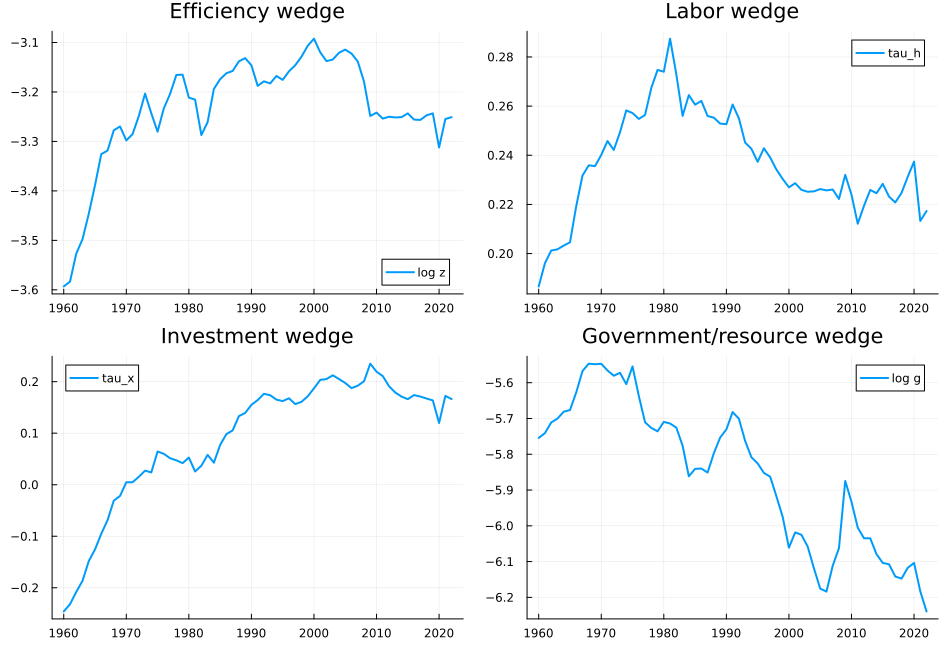

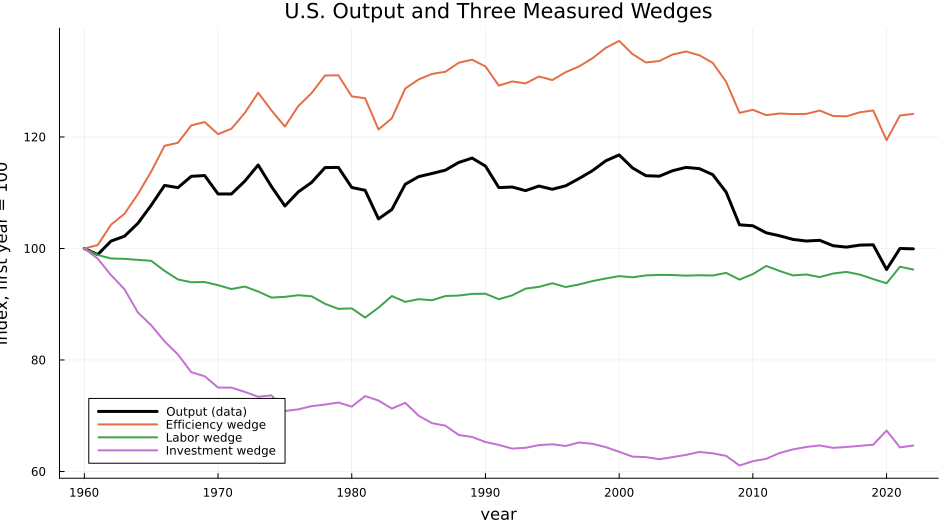

In [50]:
years = collect(bca_data.year)

# (8a) Inferred wedges as levels
p1 = plot(years, wedges.log_z, title = "Efficiency wedge",          label = "log z", linewidth = 2)
p2 = plot(years, wedges.tau_h, title = "Labor wedge",               label = "tau_h", linewidth = 2)
p3 = plot(years, wedges.tau_x, title = "Investment wedge",          label = "tau_x", linewidth = 2)
p4 = plot(years, wedges.log_g, title = "Government/resource wedge", label = "log g", linewidth = 2)
p_wedges = plot(p1, p2, p3, p4, layout = (2, 2), size = (950, 650))
display(p_wedges)

# (8b) CKM Figure-5 style: normalised wedges and data output on one axis
theta_a    = hw7_params.theta
z_rel      = exp.(wedges.log_z .- wedges.log_z[1]) .^ (1.0 - theta_a)
tauh_rel   = (1.0 .- wedges.tau_h) ./ (1.0 - wedges.tau_h[1])
taux_rel   = (1.0 + wedges.tau_x[1]) ./ (1.0 .+ wedges.tau_x)
y_data_rel = exp.(Yobs[:, 1]) ./ exp(Yobs[1, 1])

p_fig5 = plot(years, 100 .* y_data_rel, label = "Output (data)",    linewidth = 3, color = :black)
plot!(p_fig5, years, 100 .* z_rel,      label = "Efficiency wedge", linewidth = 2)
plot!(p_fig5, years, 100 .* tauh_rel,   label = "Labor wedge",      linewidth = 2)
plot!(p_fig5, years, 100 .* taux_rel,   label = "Investment wedge", linewidth = 2)
plot!(p_fig5, title = "U.S. Output and Three Measured Wedges",
      xlabel = "year", ylabel = "index, first year = 100", size = (950, 520))
display(p_fig5)


## 9. All Wedges: Model vs Data (part b)

Feeding the realised wedge paths $\{S_t\}_{t=1}^T$ back into the log-linear state-space and simulating with every column active yields $Y^{(\text{all})}_t=\hat C X_t$. Because our wedge reconstruction in Step 7 inverts the same observation equation (four shocks matching four observables, $R\to 0$), the all-wedges simulation reproduces the observed paths $(\tilde y_t,\,\tilde x_t,\,h_t)$ by construction. The plots below confirm that model and data coincide.


In [51]:
# Compute the full one-wedge accounting once; reuse level_series for parts (b) and (c).
counterfactual_output, cf_summary, level_series = bca_one_wedge_accounting(
    ss_hat, wedges, ckm_final_inputs, Yobs, years,
)

mk_idx(v) = 100 .* v ./ v[1]

# --- Part b: data vs all-wedges model for output, investment, hours ---
p_y_all = plot(years, mk_idx(level_series.y_data_level), label = "Data",       linewidth = 3, color = :black)
plot!(p_y_all, years, mk_idx(level_series.y_all_level),  label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_y_all, title = "Output", xlabel = "year", ylabel = "index, first year = 100")

p_x_all = plot(years, mk_idx(level_series.x_data_level), label = "Data",       linewidth = 3, color = :black)
plot!(p_x_all, years, mk_idx(level_series.x_all_level),  label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_x_all, title = "Investment", xlabel = "year")

p_h_all = plot(years, mk_idx(level_series.h_data_level), label = "Data",       linewidth = 3, color = :black)
plot!(p_h_all, years, mk_idx(level_series.h_all_level),  label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_h_all, title = "Hours", xlabel = "year")

p_all = plot(p_y_all, p_x_all, p_h_all, layout = (1, 3), size = (1350, 420))
display(p_all)


UndefVarError: UndefVarError: `bca_one_wedge_accounting` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

## 10. Feed Wedges Back into the Model One at a Time (part c)

With the realised wedge paths $\{\log z_t,\tau_{h,t},\tau_{x,t},\log\tilde g_t\}_{t=1}^T$, we want to study how much of the movement in $(\tilde y_t,\tilde x_t,h_t)$ can be attributed to each wedge individually.

### 10a. Counterfactual wedge paths

For each case $j\in\{\text{all, none, }z,\tau_h,\tau_x,g\}$ we build a $T\times 4$ matrix $S^{(j)}$: columns listed in $j$ use the realised path, columns not listed are frozen at their first-sample value,

$$
S^{(j)}_{t,k}=
\begin{cases}
S_{t,k}, & k\in j, \\[2pt]
S_{1,k}, & k\notin j.
\end{cases}
$$

The *none* case freezes every wedge and serves as the no-shock baseline.

### 10b. Log-linear forward simulation

Given $S^{(j)}$, we iterate the log-linear state-space system starting from $\log\tilde k_1=\log\tilde k_{ss}$. With $X_t=(\log\tilde k_t,\,S^{(j)}_t,\,1)'$, the capital policy from Step 3c and the observation equation give

$$
\log\tilde k_{t+1}=\gamma' X_t,\qquad Y_t^{(j)}=\hat C\, X_t,
$$

where $\gamma$ is the first row of $\hat A$.

### 10c. Level contribution relative to the no-shock baseline

For each observable (output, investment, hours) and each case $j$, the contribution is

$$
v_t^{(j),\text{contrib}}=\big(v_t^{(j)}-v_t^{(\text{none})}\big)-\big(v_1^{(j)}-v_1^{(\text{none})}\big)+v_1^{\text{data}},
$$

normalised to $100$ at $t=1$ and plotted alongside the data.


In [ ]:
# --- Part c: one-wedge accounting for output, investment, hours ---
p_y = one_wedge_panel("Output",     years, level_series.y_data_level,
                      level_series.y_z_contrib, level_series.y_h_contrib,
                      level_series.y_x_contrib, level_series.y_g_contrib;
                      show_legend = true)
p_h = one_wedge_panel("Hours",      years, level_series.h_data_level,
                      level_series.h_z_contrib, level_series.h_h_contrib,
                      level_series.h_x_contrib, level_series.h_g_contrib)
p_x = one_wedge_panel("Investment", years, level_series.x_data_level,
                      level_series.x_z_contrib, level_series.x_h_contrib,
                      level_series.x_x_contrib, level_series.x_g_contrib;
                      xlab = "year")

p_one = plot(p_y, p_h, p_x, layout = (3, 1), size = (900, 900), link = :x)
display(p_one)

display(cf_summary)


### 10d. Additional counterfactual experiments

Two complementary exercises grouped into one cell:

1. **All wedges but one.** For each wedge $k$, activate the other three and freeze only column $k$ at its first-sample value. If shutting down wedge $k$ still tracks the data, that wedge was redundant for the cycle.
2. **Efficiency + labor only.** Activate $\log z_t$ and $\tau_{h,t}$ simultaneously, freeze $\tau_x$ and $\log\tilde g$. This isolates the pair that CKM identify as the main drivers.


In [ ]:
# --- Extra counterfactuals (annual) ---
abo = bca_all_but_one_accounting(ss_hat, wedges, ckm_final_inputs, Yobs, years)

# Efficiency + labor only: columns 1 and 2 active, tau_x and log g frozen at S_1
S_actual = hcat(wedges.log_z_linear, wedges.tau_h_linear, wedges.tau_x, wedges.log_g)
S_first  = vec(S_actual[1, :])
logk0    = ckm_final_inputs.lkt[1]
Y_no_base, _ = simulate_bca_observables(counterfactual_wedge_paths(Int[],    S_actual, S_first), ss_hat; logk0 = logk0)
Y_zl,      _ = simulate_bca_observables(counterfactual_wedge_paths([1, 2],  S_actual, S_first), ss_hat; logk0 = logk0)
y_data0 = abo.y_data_level[1]; x_data0 = abo.x_data_level[1]; h_data0 = abo.h_data_level[1]
y_zl = benchplots_level_contribution(Y_zl, Y_no_base, y_data0; col = 1)
x_zl = benchplots_level_contribution(Y_zl, Y_no_base, x_data0; col = 2)
h_zl = benchplots_level_contribution(Y_zl, Y_no_base, h_data0; col = 3)

# (i) All wedges but one
p_y_abo = all_but_one_panel("Output",     years, abo.y_data_level,
                            abo.y_noz_contrib, abo.y_nol_contrib,
                            abo.y_nox_contrib, abo.y_nog_contrib;
                            show_legend = true)
p_h_abo = all_but_one_panel("Hours",      years, abo.h_data_level,
                            abo.h_noz_contrib, abo.h_nol_contrib,
                            abo.h_nox_contrib, abo.h_nog_contrib)
p_x_abo = all_but_one_panel("Investment", years, abo.x_data_level,
                            abo.x_noz_contrib, abo.x_nol_contrib,
                            abo.x_nox_contrib, abo.x_nog_contrib;
                            xlab = "year")
display(plot(p_y_abo, p_h_abo, p_x_abo, layout = (3, 1), size = (900, 900), link = :x))

# (ii) Efficiency + labor only
p_y_zl = two_wedge_panel("Output",     years, abo.y_data_level, y_zl; show_legend = true)
p_h_zl = two_wedge_panel("Hours",      years, abo.h_data_level, h_zl)
p_x_zl = two_wedge_panel("Investment", years, abo.x_data_level, x_zl; xlab = "year")
display(plot(p_y_zl, p_h_zl, p_x_zl, layout = (3, 1), size = (900, 900), link = :x))


## 11. Quarterly Extension

The annual replication above is not as sharp as one would hope: the one-wedge decompositions track the data only loosely, and the estimated wedge process is visibly sensitive to the warm start. A natural suspect is the **data-to-parameter ratio**.

The wedge VAR carries

$$
\underbrace{4}_{\bar S}\;+\;\underbrace{16}_{P}\;+\;\underbrace{10}_{\text{lower-tri }Q}\;=\;30
$$

free parameters, which must be pinned down from $n_y = 4$ observable series of length $T$. The effective ratio is therefore

$$
\rho \;\equiv\; \frac{n_y\,T}{\,\text{\# parameters}\,}\;=\;\frac{4T}{30}.
$$

On the annual sample $T \approx 60$, giving $\rho \approx 8$ — too few effective observations for a $30$-dimensional likelihood, so the objective is flat along many directions and the VAR is weakly identified. Moving to a quarterly panel leaves the parameter count unchanged but pushes $T$ from $\sim 60$ to $\sim 300$, so that

$$
\rho_{\text{quarterly}} \;=\; \frac{4\cdot 300}{30}\;\approx\;40,
$$

a fivefold gain in identifying power.

We therefore re-run the entire pipeline — load, detrend, warm start, MLE, wedge reconstruction, counterfactuals — on a quarterly BEA/BLS panel spanning 1948Q1–2024Q4. The deep parameters are frequency-converted,

$$
\beta_q = \beta^{1/4}, \qquad
\gamma_{n,q} = (1+\gamma_n)^{1/4}-1, \qquad
\gamma_{z,q} = (1+\gamma_z)^{1/4}-1, \qquad
\delta_q = 1-(1-\delta)^{1/4},
$$

and the quarterly capital stock is built by perpetual inventory from the annual $K/Y$ anchor. Every helper from the annual run is reused without modification; only the loader and the calibration step change.


In [ ]:
# -------------------------------------------------------
# Load Yichen's quarterly CSV and build the per-capita BCA series.
# All real-per-capita / PI-capital construction lives in HW7Tools.jl.
# -------------------------------------------------------
bca_data_q = build_bca_quarterly_per_capita(
    joinpath(pwd(), "data", "cleaned_data_from_yichen.csv")
)

println("Quarterly: T = ", tools.nrow(bca_data_q),
        ", ", bca_data_q.year[1], " to ", bca_data_q.year[end])


In [54]:
# -------------------------------------------------------
# Quarterly calibration (frequency-converted from the annual deep params),
# detrend, Step-2 static wedges and warm-start theta0_q
# -------------------------------------------------------
hw7_params_q = (
    beta    = 0.97^(1/4),
    psi     = 1.55,
    sigma   = 2.00,
    gamma_n = (1.0 + 0.01)^(1/4) - 1.0,
    gamma_z = (1.0 + 0.02)^(1/4) - 1.0,
    theta   = 0.368,
    delta   = 1.0 - (1.0 - 0.072)^(1/4),
)

static_q  = detrend_and_static_wedges(bca_data_q, hw7_params_q)
T_q       = static_q.T
y_tilde_q = static_q.y_tilde
c_tilde_q = static_q.c_tilde
x_tilde_q = static_q.x_tilde
g_tilde_q = static_q.g_tilde
h_tilde_q = static_q.h_tilde
k_tilde_q = static_q.k_tilde
log_z_q   = static_q.log_z
tau_h_q   = static_q.tau_h
log_g_q   = static_q.log_g
Yobs_q    = static_q.Yobs

Sbar0_q   = [tools.mean(log_z_q), tools.mean(tau_h_q), 0.0, tools.mean(log_g_q)]
P_init_q  = 0.97 .* Matrix{Float64}(I, 4, 4)
Q_init_q            = zeros(4, 4)
Q_init_q[1, 1]      = tools.std(log_z_q)
Q_init_q[2, 2]      = tools.std(tau_h_q)
Q_init_q[3, 3]      = 0.01
Q_init_q[4, 4]      = tools.std(log_g_q)
theta0_q = pack_bca_theta(Sbar0_q, P_init_q, Q_init_q)

println("T_q = ", T_q,
        "  |  data obs per MLE param = ", round(4 * T_q / 30; digits = 2))
println("log z: mean = ", tools.mean(log_z_q), ", std = ", tools.std(log_z_q))
println("tau_h: mean = ", tools.mean(tau_h_q), ", std = ", tools.std(tau_h_q))
println("log g: mean = ", tools.mean(log_g_q), ", std = ", tools.std(log_g_q))


UndefVarError: UndefVarError: `detrend_and_static_wedges` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

In [55]:
# -------------------------------------------------------
# Quarterly: MLE + wedge reconstruction, then part (a) plots
# -------------------------------------------------------
theta_hat_q, final_neg_ll_q = estimate_bca_mle_nm(
    theta0_q, hw7_params_q, Yobs_q;
    max_restarts = 10, iterations = 3000, improve_tol = 0.1, verbose = true,
)

ss_hat_q = bca_state_space(theta_hat_q, hw7_params_q)
wedges_q, ckm_final_inputs_q = ckm_loglinear_reconstruction(
    ss_hat_q, hw7_params_q,
    y_tilde_q, x_tilde_q, h_tilde_q, g_tilde_q,
    log_g_q, bca_data_q.year,
)

println("Quarterly MLE neg log lik = ", final_neg_ll_q)
println("Estimated Sbar_q = ", ss_hat_q.Sbar)

yrs_q = collect(bca_data_q.year)

# (a1) Inferred wedges as levels
p1q = plot(yrs_q, wedges_q.log_z, title = "Efficiency wedge (quarterly)",  label = "log z", linewidth = 2)
p2q = plot(yrs_q, wedges_q.tau_h, title = "Labor wedge (quarterly)",       label = "tau_h", linewidth = 2)
p3q = plot(yrs_q, wedges_q.tau_x, title = "Investment wedge (quarterly)",  label = "tau_x", linewidth = 2)
p4q = plot(yrs_q, wedges_q.log_g, title = "Government wedge (quarterly)",  label = "log g", linewidth = 2)
p_wedges_q = plot(p1q, p2q, p3q, p4q, layout = (2, 2), size = (950, 650))
display(p_wedges_q)

# (a2) CKM Figure-5 style overlay for the quarterly sample
theta_q      = hw7_params_q.theta
z_rel_q      = exp.(wedges_q.log_z .- wedges_q.log_z[1]) .^ (1.0 - theta_q)
tauh_rel_q   = (1.0 .- wedges_q.tau_h) ./ (1.0 - wedges_q.tau_h[1])
taux_rel_q   = (1.0 + wedges_q.tau_x[1]) ./ (1.0 .+ wedges_q.tau_x)
y_data_rel_q = exp.(Yobs_q[:, 1]) ./ exp(Yobs_q[1, 1])

p_fig5_q = plot(yrs_q, 100 .* y_data_rel_q, label = "Output (data)",    linewidth = 3, color = :black)
plot!(p_fig5_q, yrs_q, 100 .* z_rel_q,      label = "Efficiency wedge", linewidth = 2)
plot!(p_fig5_q, yrs_q, 100 .* tauh_rel_q,   label = "Labor wedge",      linewidth = 2)
plot!(p_fig5_q, yrs_q, 100 .* taux_rel_q,   label = "Investment wedge", linewidth = 2)
plot!(p_fig5_q, title = "U.S. Output and Three Measured Wedges (quarterly)",
      xlabel = "year", ylabel = "index, 1948Q1 = 100", size = (950, 520))
display(p_fig5_q)


UndefVarError: UndefVarError: `estimate_bca_mle_nm` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

In [56]:
# -------------------------------------------------------
# Quarterly part (b): data vs all-wedges model for output, investment, hours
# -------------------------------------------------------
counterfactual_output_q, cf_summary_q, level_series_q = bca_one_wedge_accounting(
    ss_hat_q, wedges_q, ckm_final_inputs_q, Yobs_q, yrs_q,
)

mk_idx_q(v) = 100 .* v ./ v[1]

p_y_all_q = plot(yrs_q, mk_idx_q(level_series_q.y_data_level), label = "Data",       linewidth = 3, color = :black)
plot!(p_y_all_q, yrs_q, mk_idx_q(level_series_q.y_all_level),  label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_y_all_q, title = "Output", xlabel = "year", ylabel = "index, 1948Q1 = 100")

p_x_all_q = plot(yrs_q, mk_idx_q(level_series_q.x_data_level), label = "Data",       linewidth = 3, color = :black)
plot!(p_x_all_q, yrs_q, mk_idx_q(level_series_q.x_all_level),  label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_x_all_q, title = "Investment", xlabel = "year")

p_h_all_q = plot(yrs_q, mk_idx_q(level_series_q.h_data_level), label = "Data",       linewidth = 3, color = :black)
plot!(p_h_all_q, yrs_q, mk_idx_q(level_series_q.h_all_level),  label = "All wedges", linewidth = 2, linestyle = :dash)
plot!(p_h_all_q, title = "Hours", xlabel = "year")

p_all_q = plot(p_y_all_q, p_x_all_q, p_h_all_q, layout = (1, 3), size = (1350, 420))
display(p_all_q)


UndefVarError: UndefVarError: `bca_one_wedge_accounting` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

In [ ]:
# -------------------------------------------------------
# Quarterly part (c): one-wedge accounting for output, investment, hours
# -------------------------------------------------------
ylab_q = "index, 1948Q1 = 100"

p_y_q = one_wedge_panel("Output",     yrs_q, level_series_q.y_data_level,
                        level_series_q.y_z_contrib, level_series_q.y_h_contrib,
                        level_series_q.y_x_contrib, level_series_q.y_g_contrib;
                        show_legend = true, ylab = ylab_q)
p_h_q = one_wedge_panel("Hours",      yrs_q, level_series_q.h_data_level,
                        level_series_q.h_z_contrib, level_series_q.h_h_contrib,
                        level_series_q.h_x_contrib, level_series_q.h_g_contrib;
                        ylab = ylab_q)
p_x_q = one_wedge_panel("Investment", yrs_q, level_series_q.x_data_level,
                        level_series_q.x_z_contrib, level_series_q.x_h_contrib,
                        level_series_q.x_x_contrib, level_series_q.x_g_contrib;
                        xlab = "year", ylab = ylab_q)

p_one_q = plot(p_y_q, p_h_q, p_x_q, layout = (3, 1), size = (900, 900), link = :x)
display(p_one_q)

display(cf_summary_q)


### Quarterly additional counterfactuals

Same two extra experiments on the quarterly sample: all-wedges-but-one, and efficiency + labor only.


In [ ]:
# --- Extra counterfactuals (quarterly) ---
abo_q = bca_all_but_one_accounting(ss_hat_q, wedges_q, ckm_final_inputs_q, Yobs_q, yrs_q)

S_actual_q = hcat(wedges_q.log_z_linear, wedges_q.tau_h_linear, wedges_q.tau_x, wedges_q.log_g)
S_first_q  = vec(S_actual_q[1, :])
logk0_q    = ckm_final_inputs_q.lkt[1]
Y_no_base_q, _ = simulate_bca_observables(counterfactual_wedge_paths(Int[],    S_actual_q, S_first_q), ss_hat_q; logk0 = logk0_q)
Y_zl_q,      _ = simulate_bca_observables(counterfactual_wedge_paths([1, 2],  S_actual_q, S_first_q), ss_hat_q; logk0 = logk0_q)
y_data0_q = abo_q.y_data_level[1]; x_data0_q = abo_q.x_data_level[1]; h_data0_q = abo_q.h_data_level[1]
y_zl_q = benchplots_level_contribution(Y_zl_q, Y_no_base_q, y_data0_q; col = 1)
x_zl_q = benchplots_level_contribution(Y_zl_q, Y_no_base_q, x_data0_q; col = 2)
h_zl_q = benchplots_level_contribution(Y_zl_q, Y_no_base_q, h_data0_q; col = 3)

ylab_q = "index, 1948Q1 = 100"

p_y_abo_q = all_but_one_panel("Output",     yrs_q, abo_q.y_data_level,
                              abo_q.y_noz_contrib, abo_q.y_nol_contrib,
                              abo_q.y_nox_contrib, abo_q.y_nog_contrib;
                              show_legend = true, ylab = ylab_q)
p_h_abo_q = all_but_one_panel("Hours",      yrs_q, abo_q.h_data_level,
                              abo_q.h_noz_contrib, abo_q.h_nol_contrib,
                              abo_q.h_nox_contrib, abo_q.h_nog_contrib;
                              ylab = ylab_q)
p_x_abo_q = all_but_one_panel("Investment", yrs_q, abo_q.x_data_level,
                              abo_q.x_noz_contrib, abo_q.x_nol_contrib,
                              abo_q.x_nox_contrib, abo_q.x_nog_contrib;
                              xlab = "year", ylab = ylab_q)
display(plot(p_y_abo_q, p_h_abo_q, p_x_abo_q, layout = (3, 1), size = (900, 900), link = :x))

p_y_zl_q = two_wedge_panel("Output",     yrs_q, abo_q.y_data_level, y_zl_q; show_legend = true, ylab = ylab_q)
p_h_zl_q = two_wedge_panel("Hours",      yrs_q, abo_q.h_data_level, h_zl_q; ylab = ylab_q)
p_x_zl_q = two_wedge_panel("Investment", yrs_q, abo_q.x_data_level, x_zl_q; xlab = "year", ylab = ylab_q)
display(plot(p_y_zl_q, p_h_zl_q, p_x_zl_q, layout = (3, 1), size = (900, 900), link = :x))
